[ENG]

PROJECT 2 : DECATHLON

[FR]

PROJET 2 : DECATHLON


In [2]:
# Installing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from scipy.stats import pearsonr
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
# Loading Decathlon dataset
decathlon_df= pd.read_csv("C://Users//emmhu//OneDrive//Documents//E-LEARNING//DU DATA ANALYST//3_RD & Clustering//Données//Datasets//decathlon.csv", sep= ";", encoding="utf-8")

decathlon_df.head()


,Unnamed: 0,100m,Longueur,Poids,Hauteur,400m,110m H,Disque,Perche,Javelot,1500m,Classement,Points,Competition
0,Sebrle,10.85,7.84,16.36,2.12,48.36,14.05,48.72,5.0,70.52,280.01,1,8893,JO
1,Clay,10.44,7.96,15.23,2.06,49.19,14.13,50.11,4.9,69.71,282.00,2,8820,JO
2,Karpov,10.50,7.81,15.93,2.09,46.81,13.97,51.65,4.6,55.54,278.11,3,8725,JO
3,Macey,10.89,7.47,15.73,2.15,48.97,14.56,48.34,4.4,58.46,265.42,4,8414,JO
4,Warners,10.62,7.74,14.48,1.97,47.97,14.01,43.73,4.9,55.39,278.05,5,8343,JO


In [4]:
# Renaming the "unnamed:0" column
decathlon_df.rename(columns={'Unnamed: 0': 'Athlete'}, inplace=True)
decathlon_df.head()

,Athlete,100m,Longueur,Poids,Hauteur,400m,110m H,Disque,Perche,Javelot,1500m,Classement,Points,Competition
0,Sebrle,10.85,7.84,16.36,2.12,48.36,14.05,48.72,5.0,70.52,280.01,1,8893,JO
1,Clay,10.44,7.96,15.23,2.06,49.19,14.13,50.11,4.9,69.71,282.00,2,8820,JO
2,Karpov,10.50,7.81,15.93,2.09,46.81,13.97,51.65,4.6,55.54,278.11,3,8725,JO
3,Macey,10.89,7.47,15.73,2.15,48.97,14.56,48.34,4.4,58.46,265.42,4,8414,JO
4,Warners,10.62,7.74,14.48,1.97,47.97,14.01,43.73,4.9,55.39,278.05,5,8343,JO


In [5]:
# Inspecting the dataset
print(decathlon_df.shape)
print(decathlon_df.describe())
print(decathlon_df.info())

(41, 14)
            100m   Longueur      Poids    Hauteur       400m     110m H  \
count  41.000000  41.000000  41.000000  41.000000  41.000000  41.000000   
mean   10.998049   7.260000  14.477073   1.976829  49.616341  14.605854   
std     0.263023   0.316402   0.824428   0.088951   1.153451   0.471789   
min    10.440000   6.610000  12.680000   1.850000  46.810000  13.970000   
25%    10.850000   7.030000  13.880000   1.920000  48.930000  14.210000   
50%    10.980000   7.300000  14.570000   1.950000  49.400000  14.480000   
75%    11.140000   7.480000  14.970000   2.040000  50.300000  14.980000   
max    11.640000   7.960000  16.360000   2.150000  53.200000  15.670000   

          Disque     Perche    Javelot       1500m  Classement       Points  
count  41.000000  41.000000  41.000000   41.000000   41.000000    41.000000  
mean   44.325610   4.762439  58.316585  279.024878   12.121951  8005.365854  
std     3.377845   0.278000   4.826820   11.673247    7.918949   342.385145  
min

In [6]:
#Checking for missing values
missing_values= decathlon_df.isnull()
missing_values_sum= missing_values.sum()
missing_values_sum

Athlete        0
100m           0
Longueur       0
Poids          0
Hauteur        0
400m           0
110m H         0
Disque         0
Perche         0
Javelot        0
1500m          0
Classement     0
Points         0
Competition    0
dtype: int64

In [7]:
# Display the column names
print(decathlon_df.columns)

Index(['Athlete', '100m', 'Longueur', 'Poids', 'Hauteur', '400m', '110m H',
       'Disque', 'Perche', 'Javelot', '1500m', 'Classement', 'Points',
       'Competition'],
      dtype='object')


[ENG]

1. Mobilize data from the decathlon dataset, perform some dimensionality reduction analysis using PCA, and produce a circle of correlations

[FR]

1. Mobilisez les données du jeu de données sur le décathlon, effectuez quelques analyses de réduction de dimensionnalité par ACP, et produisez un cercle des corrélations

In [8]:
# Select only features (numeric values for events) for PCA
features2 = ["100m", "Longueur", "Poids", "Hauteur", "400m", "110m H", "Disque", "Perche", "Javelot", "1500m"]
X = decathlon_df[features2]

# # Standardizing features (centring and reducing)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Calculate the correlation matrix of the features
correlation_matrix2 = np.corrcoef(X_scaled, rowvar=False)
correlation_df2 = pd.DataFrame(correlation_matrix2, index=features2, columns=features2)

# Print the correlation matrix
print("Correlation matrix:\n", correlation_matrix2)


Correlation matrix:
 [[ 1.         -0.59867767 -0.35648227 -0.24625292  0.52029815  0.57988893
  -0.22170757 -0.08253683 -0.15774645 -0.06054645]
 [-0.59867767  1.          0.18330436  0.29464444 -0.60206262 -0.50541009
   0.19431009  0.20401411  0.11975893 -0.03368613]
 [-0.35648227  0.18330436  1.          0.48921153 -0.13843292 -0.25161571
   0.6157681   0.06118185  0.37495551  0.11580306]
 [-0.24625292  0.29464444  0.48921153  1.         -0.18795693 -0.28328909
   0.36921834 -0.15618074  0.17188009 -0.04490252]
 [ 0.52029815 -0.60206262 -0.13843292 -0.18795693  1.          0.54798776
  -0.11787936 -0.07929247  0.0042321   0.40810643]
 [ 0.57988893 -0.50541009 -0.25161571 -0.28328909  0.54798776  1.
  -0.32620096 -0.00270388  0.00874325  0.03754024]
 [-0.22170757  0.19431009  0.6157681   0.36921834 -0.11787936 -0.32620096
   1.         -0.1500724   0.1578898   0.2581751 ]
 [-0.08253683  0.20401411  0.06118185 -0.15618074 -0.07929247 -0.00270388
  -0.1500724   1.         -0.0300006  

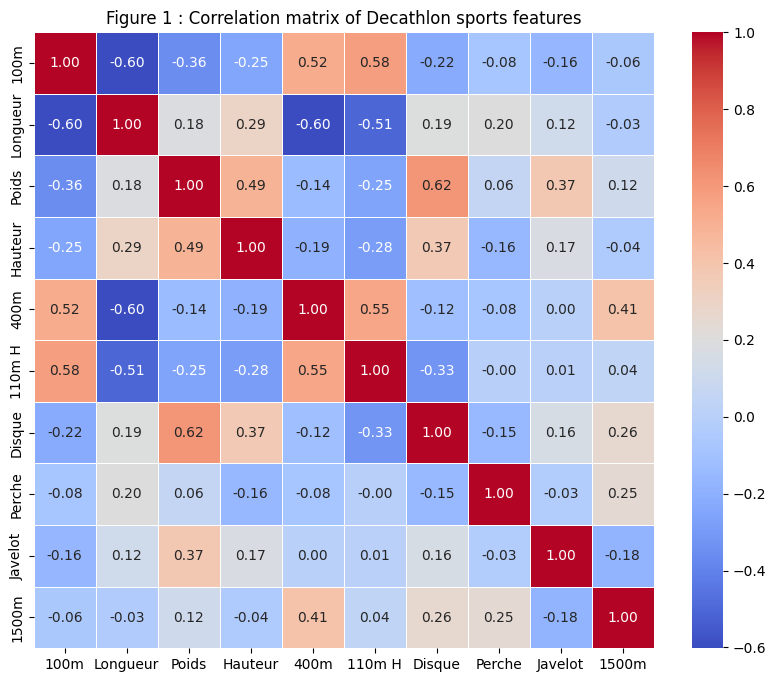

In [10]:
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df2, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Figure 1 : Correlation matrix of Decathlon sports features')
plt.savefig('Figure1_correlation_matrix_of_decathlon_sports_features', dpi= 300)
plt.show()

### Figure 1: Correlation Matrix of Decathlon Event Features

This heatmap illustrates the Pearson correlation coefficients between the different event variables in the Decathlon dataset. Correlation values range from **-1 (strong negative correlation)** to **+1 (strong positive correlation)**, with color intensity representing the strength and direction of the relationship.

**Key Observations:**
- The strongest **positive correlations** appear between:
  - **Poids (Shot Put)** and **Disque (Discus)**: *r = 0.62*
  - **100m** and **110m Hurdles**: *r = 0.58*
  - **400m** and **110m Hurdles**: *r = 0.55*

- Notable **negative correlations** include:
  - **100m** and **Longueur (Long Jump)**: *r = -0.60*
  - **400m** and **Longueur**: *r = -0.60*
  - **100m** and **Disque**: *r = -0.22*

- Some events show **little or no correlation**, such as:
  - **Perche (Pole Vault)** and **most other variables**
  - **Javelot (Javelin Throw)** with low or mixed correlations across the board

**Interpretation:**
This matrix helps identify clusters of related physical attributes (e.g., explosive power, speed, endurance) that may influence multiple events. These relationships are valuable when performing dimensionality reduction (e.g., PCA) or clustering athletes based on performance profiles.


In [11]:
# Perform PCA to reduce dimensionality
pca = PCA(n_components=10)  # Use all components to analyze the variance
X_pca = pca.fit_transform(X_scaled)

In [12]:
# Explained Variance (Eigenvalues)
# These are the eigenvalues, which show how much variance each principal component explains
explained_variance = pca.explained_variance_
print(f"Explained Variance (Eigenvalues): {explained_variance}")

Explained Variance (Eigenvalues): [3.35370318 1.7805593  1.4400396  1.08327161 0.70189287 0.6142504
 0.46251615 0.4067985  0.22018522 0.18678317]


In [13]:
# Explained Variance Ratio
# This shows the proportion of variance explained by each component
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance_ratio}")

Explained Variance Ratio: [0.32719055 0.1737131  0.14049167 0.10568504 0.06847735 0.05992687
 0.04512353 0.03968766 0.02148149 0.01822275]


In [14]:
# Display  a sum of explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance ratio by PC1: {explained_variance[0]:.4f}')
print(f'Explained variance ratio by PC2: {explained_variance[1]:.4f}')
print(f'Explained variance ratio by PC3: {explained_variance[2]:.4f}')
print(f'Explained variance ratio by PC4: {explained_variance[3]:.4f}')
print(f'Explained variance ratio by PC5: {explained_variance[4]:.4f}')
print(f'Explained variance ratio by PC6: {explained_variance[5]:.4f}')
print(f'Explained variance ratio by PC7: {explained_variance[6]:.4f}')
print(f'Explained variance ratio by PC8: {explained_variance[7]:.4f}')
print(f'Explained variance ratio by PC9: {explained_variance[8]:.4f}')
print(f'Explained variance ratio by PC10: {explained_variance[9]:.4f}')

print(f'Total explained variance ratio: {np.sum(explained_variance):.4f}')

Explained variance ratio by PC1: 0.3272
Explained variance ratio by PC2: 0.1737
Explained variance ratio by PC3: 0.1405
Explained variance ratio by PC4: 0.1057
Explained variance ratio by PC5: 0.0685
Explained variance ratio by PC6: 0.0599
Explained variance ratio by PC7: 0.0451
Explained variance ratio by PC8: 0.0397
Explained variance ratio by PC9: 0.0215
Explained variance ratio by PC10: 0.0182
Total explained variance ratio: 1.0000


In [15]:
# Create a dataframe to summarise variance
variance_df2 = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Explained Variance': pca.explained_variance_,
    'Explained Variance Ratio': pca.explained_variance_ratio_
})

print(variance_df2)


  Principal Component  Explained Variance  Explained Variance Ratio
0                 PC1            3.353703                  0.327191
1                 PC2            1.780559                  0.173713
2                 PC3            1.440040                  0.140492
3                 PC4            1.083272                  0.105685
4                 PC5            0.701893                  0.068477
5                 PC6            0.614250                  0.059927
6                 PC7            0.462516                  0.045124
7                 PC8            0.406799                  0.039688
8                 PC9            0.220185                  0.021481
9                PC10            0.186783                  0.018223


In [16]:
# Display Eigenvalues
eig2 = pd.DataFrame(
    {
        "Dimension": ["Dim" + str(x + 1) for x in range(10)], 
        "Eigen-values (Variance expliquée)": pca.explained_variance_[:10],
        "% variance expliquée": np.round(pca.explained_variance_ratio_[:10] * 100, 2),
        "% cum. var. expliquée": np.round(np.cumsum(pca.explained_variance_ratio_[:10]) * 100, 2)
    }
)

eig2

,Dimension,Eigen-values (Variance expliquée),% variance expliquée,% cum. var. expliquée
0,Dim1,3.353703,32.72,32.72
1,Dim2,1.780559,17.37,50.09
2,Dim3,1.440040,14.05,64.14
3,Dim4,1.083272,10.57,74.71
4,Dim5,0.701893,6.85,81.56
5,Dim6,0.614250,5.99,87.55
6,Dim7,0.462516,4.51,92.06
7,Dim8,0.406799,3.97,96.03
8,Dim9,0.220185,2.15,98.18
9,Dim10,0.186783,1.82,100.00


### PCA Results: Eigenvalues and Variance Explained (Top 10 Dimensions)
This table summarizes the output of a PCA (Principal Component Analysis), displaying how much variance each of the first 10 principal components contributes to the dataset.

####Column Descriptions:
- **Dimension**: Labels for each principal component (Dim1 to Dim10).
- **Eigen-values (Variance expliquée)**: The raw variance captured by each component, corresponding to the eigenvalues of the covariance matrix.
- **% variance expliquée**: The percentage of total variance explained by each individual component (rounded to 2 decimal places).
- **% cum. var. expliquée**: The cumulative variance explained up to each component, useful for identifying how many components are needed to retain a given percentage of information (e.g., 90%, 95%).

####Interpretation:
- The first few components (Dim1 to Dim4) capture most of the variance (≈ 75%).
- By Dim7, about **92%** of the variance is explained.
- This table is essential for selecting the optimal number of components for dimensionality reduction, balancing interpretability and data retention.

**Use Case**: You can use this summary to decide where to truncate PCA components — e.g., if you want to preserve at least 90% of the variance, the first 7 components may be sufficient.


In [18]:
# Calculate the contribution (loadings) of each feature to the first few principal components
loadings2 = pca.components_.T * np.sqrt(pca.explained_variance_)

# Convert loadings to a DataFrame for easy visualization
loadings_df2 = pd.DataFrame(loadings2, columns=features2, index=[f'PC{i+1}' for i in range(len(features2))])

# Display the loadings DataFrame to check the contributions
print(loadings_df2.head())

         100m  Longueur     Poids   Hauteur      400m    110m H    Disque  \
PC1  0.784344  0.189467 -0.186698 -0.038288  0.305951 -0.232048  0.259640   
PC2 -0.751116 -0.349712  0.184475  0.103050  0.037134  0.239923  0.426885   
PC3 -0.630236  0.605736 -0.023669  0.192959  0.112532 -0.239412 -0.210640   
PC4 -0.579050  0.354645 -0.262736 -0.137279  0.562340  0.366612 -0.062194   
PC5  0.688053  0.576512  0.133103  0.029666 -0.088781  0.260611 -0.084617   

       Perche   Javelot     1500m  
PC1 -0.294413  0.049156 -0.183368  
PC2  0.013401  0.226487 -0.035026  
PC3  0.200227  0.200501 -0.168675  
PC4 -0.079784 -0.114335  0.045996  
PC5 -0.136107  0.259081  0.178922  


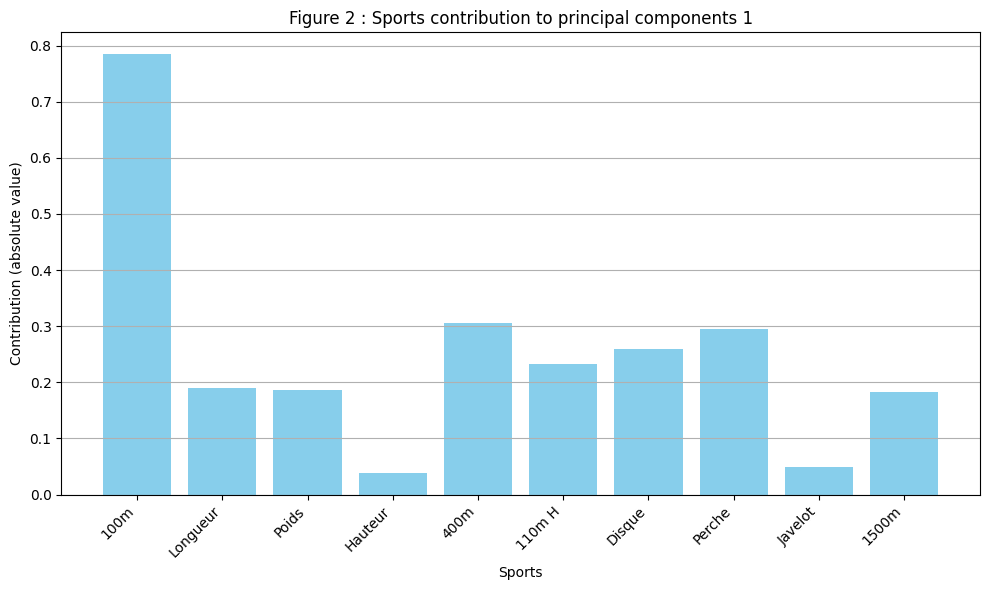

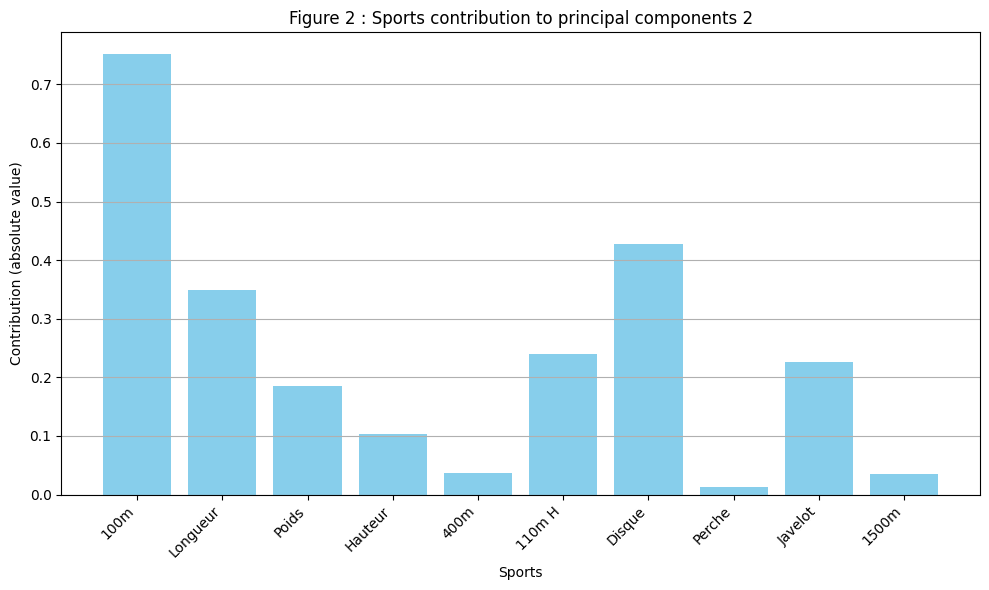

In [19]:
# Plot the contribution of each sport to Principal Component 1 and Principal Component 2
for i in range(2):  # Plot for the first two components
    plt.figure(figsize=(10, 6))
    plt.bar(loadings_df2.columns, loadings_df2.iloc[i].abs(), color='skyblue')
    plt.title(f'Figure 2 : Sports contribution to principal components {i+1}')
    plt.xlabel('Sports')
    plt.ylabel('Contribution (absolute value)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('Figure2_sports_contribution_to_principal_components.png', dpi= 300)
    plt.show()

### PCA Component 1 — Sports Event Contributions (Loadings)

The bar chart (Figure 2) visualizes the **absolute contribution** of each sport (feature) to **Principal Component 1 (PC1)** in a decathlon dataset. This is based on the **loadings (coefficients)** of each original variable in the PCA transformation (seen in the table).


#### Numerical Loadings for PC1:
| Sport       | Loading (PC1) |
|-------------|----------------|
| 100m        | **0.7834**      |
| Longueur    | 0.1805          |
| Poids       | -0.1867         |
| Hauteur     | -0.0833         |
| 400m        | 0.3096          |
| 110m H      | -0.2320         |
| Disque      | 0.2596          |
| Perche      | -0.2944         |
| Javelot     | 0.0492          |
| 1500m       | -0.1834         |

> **Note**: The chart shows the **absolute values** of these loadings to compare the strength of each sport's contribution without regard to sign (direction).

#### 🔍 Interpretation:
- **100m sprint** dominates PC1 with a loading of **0.7834**, indicating that this event has the strongest influence in defining the first principal axis.
- Other relevant contributors include:
  - **400m** (0.3096),
  - **Perche** (-0.2944),
  - **Disque** (0.2596),
  - **110m H** (-0.2320).
- Events like **Javelot** (0.0492) and **Hauteur** (-0.0833) contribute less to PC1.

#### Conclusion:
Principal Component 1 seems to be driven mostly by **explosive speed and power** events, particularly short sprints (100m, 400m) and explosive field events (pole vault, discus). PC1 likely reflects a **"power/speed" performance dimension** in decathlon athletes.



### PCA Component 2 — Contribution of Sports Events (Loadings)

This bar chart (Figure 2) displays the **absolute contribution** of each sport to the second principal component (**PC2**) derived from PCA applied to decathlon performance data.

#### Loadings for PC2 (from the PCA matrix):
| Sport       | Loading (PC2) |
|-------------|----------------|
| 100m        | **-0.7511**     |
| Longueur    | -0.3497         |
| Poids       | 0.1845          |
| Hauteur     | 0.1031          |
| 400m        | 0.0371          |
| 110m H      | 0.2399          |
| Disque      | 0.4269          |
| Perche      | 0.0134          |
| Javelot     | **0.2265**      |
| 1500m       | -0.0531         |

> The bars represent the **absolute values** of these loadings to highlight the **magnitude** of influence, regardless of direction (sign).

#### Interpretation:
- The **100m** sprint remains the strongest contributor (|−0.7511| ≈ **0.75**), indicating a key role in PC2 as well.
- **Disque** (0.4269), **Longueur** (−0.3497), and **Javelot** (0.2265) also contribute significantly.
- Events like **400m**, **Perche**, and **1500m** have minimal contributions to PC2.

#### Insight:
While PC1 was driven mostly by **speed/power**, PC2 seems to **capture a contrast or balance** between running and throwing events. The **signs** of the loadings suggest PC2 might separate athletes with different strength vs. agility profiles — though absolute values in the plot don't reflect direction.

---

This type of loading analysis is helpful in understanding the role and clustering of features within latent dimensions extracted by PCA.*


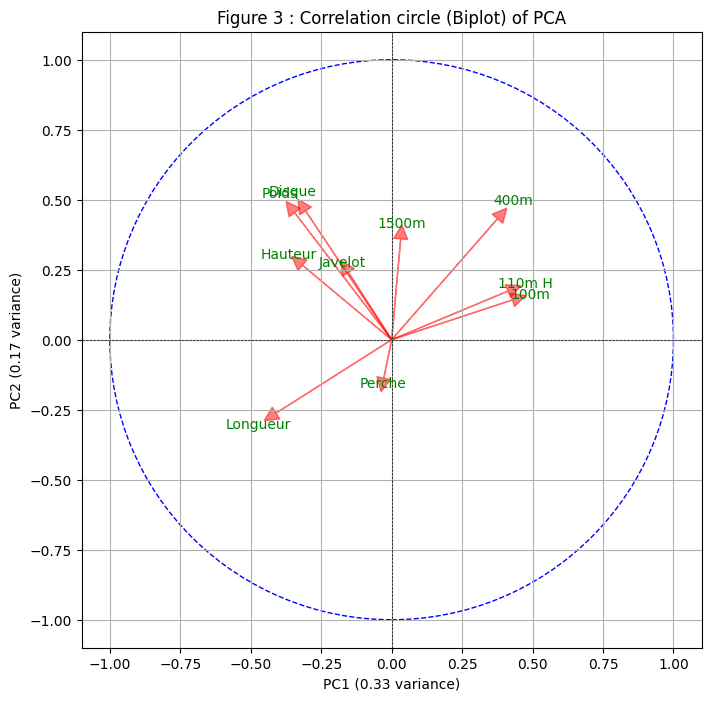

In [20]:
# Create the correlation circle (biplot)
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the correlation circle
for i in range(len(features2)):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i],
              color='r', alpha=0.5, head_width=0.05, head_length=0.05)
    plt.text(pca.components_[0, i] * 1.15, pca.components_[1, i] * 1.15, features2[i], color='g', ha='center', va='center')

# Add a circle boundary
circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='b', linestyle='--')
ax.add_artist(circle)

# Label the axes
plt.xlabel(f'PC1 ({explained_variance[0]:.2f} variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2f} variance)')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid()
plt.title('Figure 3 : Correlation circle (Biplot) of PCA')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.savefig('Figure3_Correlation_circle_(Biplot)_of_PCA', dpi= 300)

# Show the plot
plt.show()

### Figure 3: PCA Correlation Circle (Biplot)

This plot is a **correlation circle** (also known as a PCA biplot) showing how the original variables (sports events) relate to the **first two principal components (PC1 and PC2)**.

#### Key Elements:
- **Red arrows** represent the **original features** (sports), projected onto the new PCA space.
- The **x-axis** (PC1) explains **33%** of the total variance.
- The **y-axis** (PC2) explains **17%** of the total variance.
- The **blue unit circle** helps interpret correlations:
  - Arrows close to the **circle's edge** are well represented by the first two components.
  - Arrows near the **center** are poorly represented in this plane.

#### Interpretation:
- **100m**, **400m**, and **110m H** point in the same direction along PC1, suggesting they are positively correlated and strongly contribute to the first component (speed/power).
- **Longueur** points in the opposite direction along PC1, indicating a potential negative relationship with the sprint events on this axis.
- **Disque**, **Poids**, and **Hauteur** have strong vertical components, contributing more to **PC2**.
- **Perche** lies close to the origin, meaning it is weakly correlated with both PC1 and PC2 (not well represented in this plane).

#### What This Tells Us:
- The biplot helps interpret the **meaning of PCs** based on variable relationships.
- You can also assess variable **groupings**, **redundancies**, and **oppositions** in how they influence the PCA space.

---

This figure is crucial for understanding the structure of the data in the reduced-dimension space, helping to interpret what each principal component represents in terms of original variables.


[ENG]

2. In a second figure, represent the individuals on a factorial plane. The size of the bubbles representing the individuals should be related to the quality of their representation.

[FR]

2. Dans une seconde figure, représentez les individus sur un plan factoriel. La taille des bulles représentant les individus doit être liée à la qualité de leur représentation.

In [21]:
# Select only features (numeric values for events) for PCA
features2 = ["100m", "Longueur", "Poids", "Hauteur", "400m", "110m H", "Disque", "Perche", "Javelot", "1500m"]
X = decathlon_df[features2]

In [23]:
# Standardizing features (centring and reducing)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA to reduce dimensionality
pca = PCA(n_components=len(features2))  # Use all components to analyze the variance
X_pca = pca.fit_transform(X_scaled)

In [24]:
# Calculating the quality of representation (cos²) for each individual
cos2_2 = (X_pca ** 2).sum(axis=1) / (X_scaled ** 2).sum(axis=1)

# Normalizing the cos² values to scale bubble sizes
cos2_2_normalized = (cos2_2 - cos2_2.min()) / (cos2_2.max() - cos2_2.min())

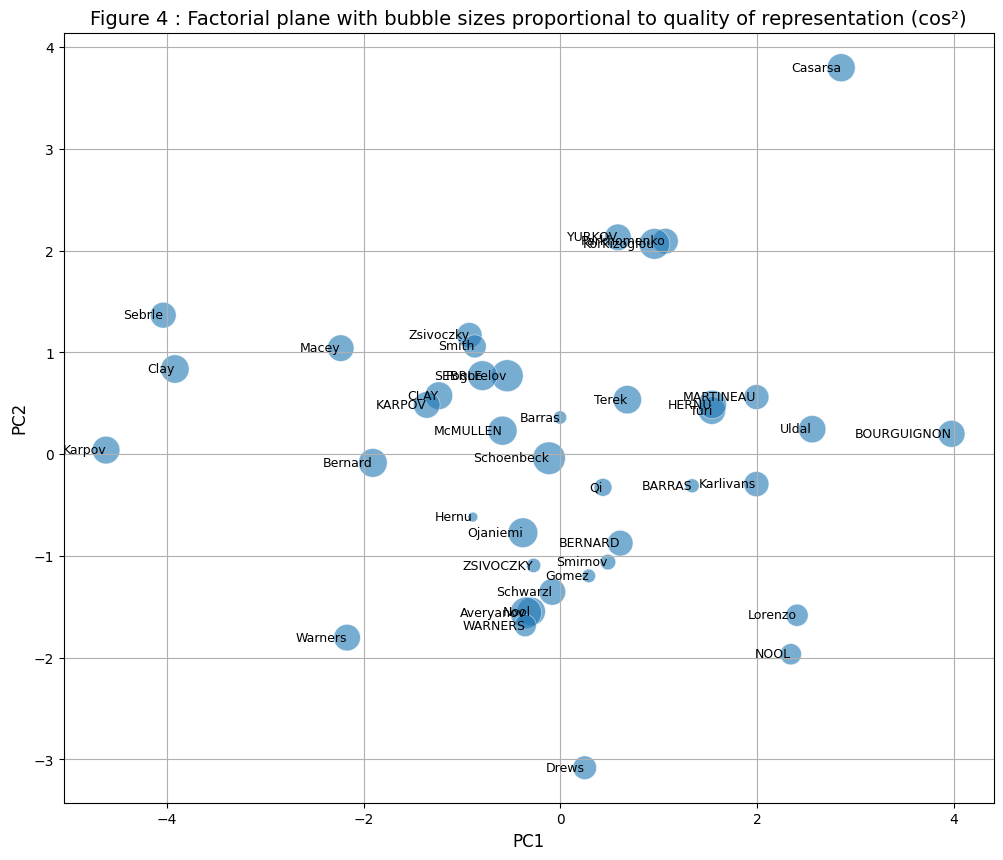

In [25]:
# Plotting the factorial plane with bubble sizes proportional to cos²
plt.figure(figsize=(12, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=(cos2_2_normalized + 0.1) * 500, alpha=0.6, edgecolors='w', linewidth=0.5)

# Adding the athletes' names to the plot
for i, name in enumerate(decathlon_df['Athlete']):
    plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=9, ha='right', va='center')

# Adding titles and labels
plt.title('Figure 4 : Factorial plane with bubble sizes proportional to quality of representation (cos²)', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.grid(True)

plt.savefig('Figure4_Factorial_plane_with_bubble_sizes_proportional_to_quality_of_representation_(cos²).png', dpi= 300)
plt.show()

### Figure 4: Individuals on the Factorial Plane (PC1 vs PC2)

This plot shows the projection of individuals (athletes) onto the first two principal components (PC1 and PC2), which summarize the main sources of variation in the original dataset.

#### How to read the axes:
- **PC1 (x-axis)** and **PC2 (y-axis)** are new dimensions created by PCA.
- PC1 explains the largest portion of variance (e.g. 33%), and PC2 explains the next largest (e.g. 17%).
- The coordinates of each athlete on the plane reflect their position along these new dimensions, which are weighted combinations of the original sports performance variables.
- For example, if PC1 is mostly influenced by sprint and speed events, then athletes far to the right might have strong sprinting profiles, while those to the left may perform better in contrasting disciplines.

#### Bubble size:
- The **size of the bubble** corresponds to the **cos² value** (squared cosine), which measures how well the individual is represented by the plane formed by PC1 and PC2.
- Large bubbles = athlete is well described by these two components.
- Small bubbles = athlete's variance lies in other components (e.g., PC3, PC4…).

#### Interpreting athlete positions:
- **Athletes close together** on the plane tend to have **similar performance profiles** based on the variables included in the PCA.
- Athletes **far from the origin** (0,0) are more distinct and carry stronger signals on these components.
- **Casarsa** (top right) stands out from the rest, suggesting a very specific profile strongly captured by PC1 and PC2.
- Those near the center (e.g., Zsivoczky, Bernard) are more average or balanced across the measured variables.

This visualization helps identify **extreme profiles**, **clusters**, and **outliers**, and provides insight into the latent dimensions that structure the athlete dataset.



[ENG]

5. Specify the respective advantages and disadvantages of the kmeans and CAH methods.

[FR]

5. Précisez les avantages et inconvénients respectifs des méthodes kmeans et CAH.

### Comparison of Unsupervised Classification Methods: K-Means vs Hierarchical Ascendant Classification (HAC/CAH)

**K-Means** and **Hierarchical Ascendant Classification (HAC or CAH)** are two widely used unsupervised learning techniques for clustering data. Each method has its strengths and limitations, and the choice depends on the dataset and analysis goals.

---

### 1. K-Means Clustering

#### Advantages:
- **Simple and fast**: Easy to implement and computationally efficient, especially on large datasets.
- **Scalable**: Handles millions of data points well.
- **Clear cluster assignment**: Each point belongs to one well-defined cluster.
- **Effective with spherical clusters**: Works well when clusters are similar in size and shape (e.g. isotropic or spherical).

#### Disadvantages:
- **Requires predefined number of clusters**: You must set `k` in advance.
- **Sensitive to initial centroids**: Results can vary; multiple initializations may be needed (e.g. `k-means++`).
- **Sensitive to outliers**: Outliers can significantly affect cluster centers due to reliance on Euclidean distance.
- **Not ideal for irregular shapes**: Performs poorly on clusters with non-spherical, elongated, or complex forms.

---

### 2. Hierarchical Ascendant Classification (HAC/CAH)

#### Advantages:
- **No need to predefine cluster number**: A full hierarchy is built first; you can choose clusters by cutting the dendrogram.
- **Handles complex cluster shapes**: Better suited for data with non-linear or varied structures.
- **Visual interpretation**: Dendrograms help explore relationships and select an appropriate cluster structure.

#### Disadvantages:
- **Computationally expensive**: Slower than K-means, especially on large datasets, due to distance matrix calculations.
- **Less scalable**: Not recommended for very large datasets.
- **Irreversible merges**: Once two clusters are joined, they cannot be split—making the method sensitive to noise or small errors.

---

### 🔍 Method Comparison Summary

| **Criterion**            | **K-Means**                              | **HAC / CAH**                             |
|--------------------------|------------------------------------------|-------------------------------------------|
| Number of clusters       | Must be set before clustering            | Selected after dendrogram construction    |
| Cluster shape            | Assumes spherical clusters               | Can handle complex shapes                 |
| Scalability              | Highly scalable                          | Limited scalability                       |
| Robustness to outliers   | Sensitive                                | Somewhat sensitive (early merges matter)  |
| Interpretation           | Easy to interpret, but initialization-dependent | Visual and intuitive (dendrogram-based) |

---

### When to Use Each Method?

#### Use **K-Means** if:
- You have a **large dataset**.
- You **know the number of clusters** in advance.
- Clusters are **well-separated and spherical**.

#### Use **HAC / CAH** if:
- You **don’t know the number of clusters**.
- You want to **explore the structure** and **relationships** in the data.
- Clusters have **irregular, non-linear shapes**.

---

Both methods are powerful tools. The right choice depends on the **data characteristics** and the **objective of the analysis**. In practice, it's often useful to try both methods and compare results.


[ENG]

6. Carry out a clustering by kmeans, then one by CAH, and represent the clusters thus created on the factorial plane. One figure per method.

[FR]

6. Réalisez un clustering par kmeans, puis un par CAH, et représentez les clusters ainsi crées sur le plan factoriel. Une figure par méthode.

In [26]:
# Select only the features (numeric values for events) for PCA
features2 = decathlon_df[["100m", "Longueur", "Poids", "Hauteur", "400m", "110m H", "Disque", "Perche", "Javelot", "1500m"]]
divers= decathlon_df[["Athlete", "Classement", "Points", "Competition"]]


In [27]:
# Standardizing data
scaler= StandardScaler()
scaled_features2= scaler.fit_transform(features2)

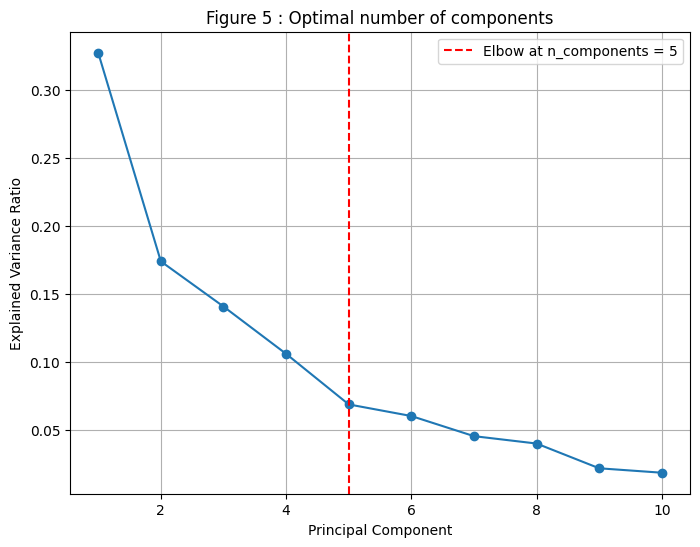

In [28]:
# Plot the scree plot to find number of components
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
plt.title('Figure 5 : Optimal number of components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.axvline(x=5, color='red', linestyle='--', label='Elbow at n_components = 5')
plt.legend()

plt.savefig('Figure5_optimal_number_of_components.png', dpi= 300)
plt.show()

### Figure 5: Optimal Number of Principal Components (Elbow Method)

This line chart shows the **explained variance ratio** for each of the first 10 principal components. The goal is to identify the optimal number of components to retain, balancing dimensionality reduction and information preservation.

#### How to interpret the plot:
- The **x-axis** represents the principal components (PC1 to PC10).
- The **y-axis** shows the proportion of variance explained by each component.
- The **"elbow" point** is where the curve starts to level off — adding more components beyond this point yields diminishing returns in explained variance.

#### Observation:
- The elbow occurs at **component 5** (highlighted by the red dashed line).
- This suggests that **retaining 5 components** captures most of the important structure in the data, while reducing noise and complexity.

Using the elbow method is a common and intuitive approach in PCA to choose the number of dimensions to keep in subsequent analysis.


In [29]:
# Apply the PCA
pca6= PCA(n_components=5)
scaled_pca6= pca6.fit_transform(scaled_features2)

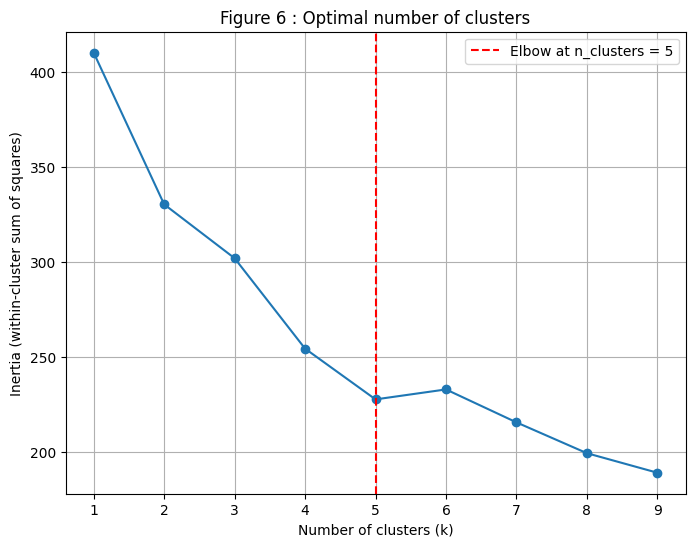

In [30]:
# Scree plot to find the number of clusters

inertia= []

for i in range(1,10):
    kmeans= KMeans(n_clusters= i, random_state= 42)
    kmeans.fit(scaled_features2)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Figure 6 : Optimal number of clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.grid(True)
plt.axvline(x=5, color='red', linestyle='--', label='Elbow at n_clusters = 5')
plt.legend()

plt.savefig('Figure6_optimal_number_of_clusters', dpi= 300)
plt.show()

### Figure 6: Optimal Number of Clusters (Elbow Method – K-Means)

This graph displays the **inertia** (within-cluster sum of squares) as a function of the number of clusters `k` for K-Means clustering.

#### How to read the plot:
- The **x-axis** shows the number of clusters tested.
- The **y-axis** shows the **inertia**, which measures the compactness of the clusters (lower values are better).
- The **goal** is to find the point where adding more clusters results in a **diminishing reduction in inertia** — this point is called the **elbow**.

#### Observation:
- The elbow appears clearly at **k = 5**, marked by the red dashed line.
- This suggests that **5 clusters** is an appropriate choice: it balances reducing intra-cluster variability while avoiding overfitting or creating unnecessarily many clusters.

#### Why it matters:
Selecting the optimal number of clusters is crucial to ensure **interpretable**, **meaningful**, and **efficient** clustering. The elbow method offers a simple visual criterion for this choice.

> This figure should be interpreted alongside domain knowledge and other metrics (e.g. silhouette score) when deciding on the final number of clusters.


In [31]:
# Create a k-means clustering model à partir des données précédantes
kmeans_optimal = KMeans(n_clusters=5, init='k-means++', n_init=20)

# Fit the data to the model
kmeans_optimal.fit(scaled_pca6)

# Determine which clusters each data point belongs to:
#  We could also use kmeans.labels_ : It is equivalent to calling the predict() method on the KMeans object after fitting it to the data. 
clusters =  kmeans_optimal.predict(scaled_pca6)

# Create a DataFrame for the PCA-transformed data and add the cluster labels
pca_columns = [f'PC{i+1}' for i in range(scaled_pca6.shape[1])]
kmeans_opti = pd.DataFrame(scaled_pca6, columns=pca_columns, index=features2.index)

# Add cluster number to the original data
kmeans_opti['Cluster'] = clusters

kmeans_opti.head()

,PC1,PC2,PC3,PC4,PC5,Cluster
0,-4.038449,1.365826,-0.289957,1.941134,0.376955,0
1,-3.919365,0.836961,0.231175,1.493972,-1.037609,0
2,-4.619987,0.039995,-0.041586,-1.313526,0.187730,0
3,-2.233461,1.041766,-1.864362,-0.743214,0.977270,1
4,-2.168396,-1.803200,0.851017,-0.284600,-0.151395,4


In [32]:
print(kmeans_optimal.cluster_centers_)

[[-4.19260031  0.74759422 -0.03345566  0.70719352 -0.15764148]
 [-0.57141297 -0.10776379 -1.15716899 -0.33749464 -0.18966518]
 [-0.3807879   0.86716018  1.84460741 -0.4452905   0.12372713]
 [ 2.01887843  0.48245487 -0.32035746  0.03323057  0.16129064]
 [-0.31338216 -1.49275458  0.84538     0.52516641  0.00888202]]


In [ ]:
# Add the Athlete column to the features2 dataframe
kmeans_opti['Athlete'] = divers['Athlete']

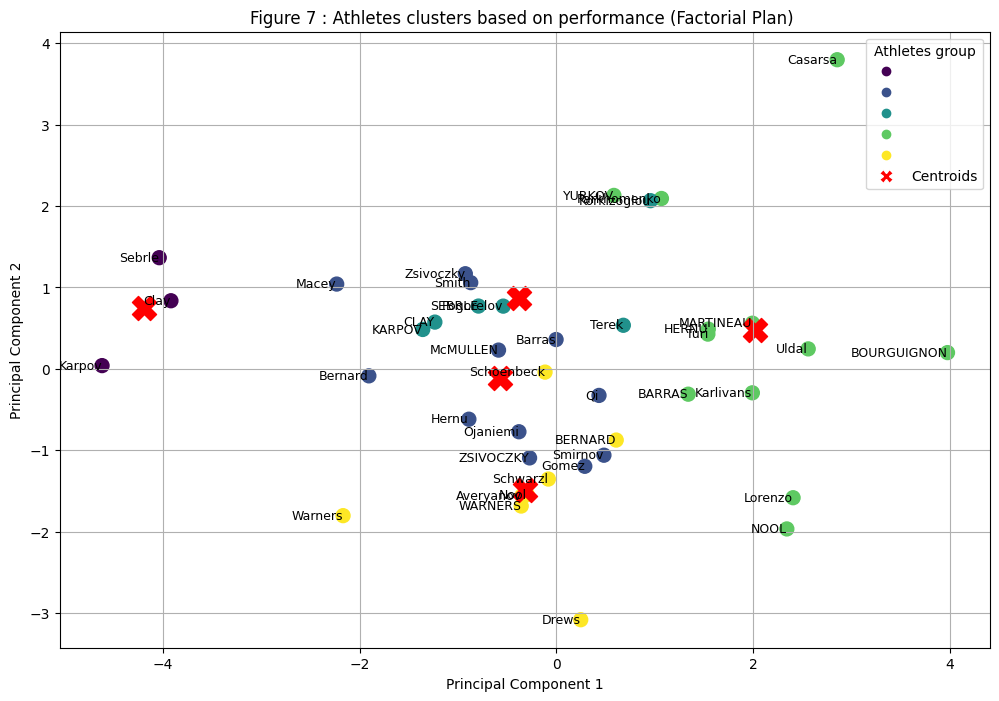

In [33]:
# Plotting the 5 clusters on the factorial plane
plt.figure(figsize=(12, 8))
scatter = plt.scatter(kmeans_opti['PC1'], kmeans_opti['PC2'], c=kmeans_opti['Cluster'], cmap='viridis', s=100)

# Plotting the centroids - this should plot 5 centroids (as per n_clusters=5)
centroids= plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')


# Annotating each point with the name of the athlete
for i, name in enumerate(divers['Athlete']):
    plt.text(kmeans_opti['PC1'].iloc[i], kmeans_opti['PC2'].iloc[i], name, fontsize=9, ha='right', va='center')

# Adding labels and legend
plt.title('Figure 7 : Athletes clusters based on performance (Factorial Plan) ')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
handles, labels = scatter.legend_elements()  # Get the graphical markers (handles) and labels from the scatter plot
handles.append(plt.Line2D([0], [0], marker='X', color='w', label='Centroids', markerfacecolor='red', markersize=10))  # Add centroids

plt.legend(handles=handles, title='Athletes group') # Ajouter une légende pour les clusters et les centroids
plt.grid(True)
plt.savefig('Figure7_Athletes_clusters_based_on_performance_(Factorial_plan).png', dpi=300)
plt.show()

### Figure 7: Athletes Clusters Based on Performance (Factorial Plane)

This figure presents the results of **K-Means clustering** applied to athletes' performances, projected onto the first two principal components (PC1 and PC2) obtained from PCA.

---

#### Clusters:
- The figure shows **5 distinct clusters**, as determined by the elbow method.
- Each athlete is represented by a labeled point on the factorial plane.
- The color of each point corresponds to its assigned cluster:
  - **Cluster 0** – Purple  
  - **Cluster 1** – Blue  
  - **Cluster 2** – Teal  
  - **Cluster 3** – Green  
  - **Cluster 4** – Yellow

#### Centroids:
- The **red ‘X’ markers** represent the centroids (mean positions) of each cluster.
- Each centroid provides a reference point around which athletes in the corresponding group are distributed.
- The presence of 5 centroids confirms the clustering was correctly performed with `k = 5`.

---

#### Interpretation of Athlete Placement:
- **Athletes like Sebrle, Clay, and Karpov**, grouped in **Cluster 0 (Purple)**, are positioned on the **left side of the plane**, indicating a shared performance profile along the first two PCs.
- **Casarsa**, a member of **Cluster 2 (Teal)**, stands out far in the **top-right quadrant**, suggesting a highly unique performance pattern.
- **Cluster 1 (Blue)** spans a wide area, indicating that although athletes are grouped together, their individual profiles vary more than in compact clusters.

---

#### Cluster Compactness:
- **Clusters 4 (Yellow)** and **1 (Blue)** appear more compact, meaning athletes within them exhibit **similar performance characteristics** after dimensionality reduction.
- **Clusters 2 (Teal)** and **0 (Purple)** are more dispersed, implying **greater variability** among athletes in those groups.

---

#### Summary of Cluster Characteristics:
- **Cluster 0 (Purple)**: Includes elite athletes like Sebrle, Clay, and Karpov — possibly those with strong, balanced performances.
- **Cluster 2 (Teal)**: Contains **Casarsa**, who is distant from all others — likely an outlier or specialist with a unique profile.
- **Cluster 4 (Yellow)**: Includes **Warner and Drew**, found in the bottom-left quadrant — possibly sharing a distinct strength or weakness.
- **Cluster 1 (Blue)**: Athletes spread across the center and lower right — suggesting moderate but varied profiles.

---

This factorial plane, combining PCA and K-means, helps visualize how athletes group together based on underlying performance patterns, and highlights both similarity and uniqueness across the dataset.


### Is the 2D Cluster Plot Accurate Given the Dimensionality Reduction?

**Knowing that the original dataset had 10 variables (e.g. decathlon events), and that dimensionality was reduced to 5 principal components before applying K-means clustering with 5 clusters, can this 2D graph still be considered an accurate representation of the clustering structure?**

This is a crucial question when interpreting the factorial plane (PC1 vs PC2) in the context of high-dimensional data and dimensionality reduction.



### Accuracy of the 2D Cluster Visualization Based on PCA (PC1 vs PC2)

This graph shows the K-means clustering of athletes visualized on the first two principal components (PC1 and PC2) after reducing the original 10-dimensional space to 5 dimensions using PCA.

#### 1. Dimensionality Reduction from 10 to 5 Components
- PCA was used to reduce the dataset from 10 original features (likely 10 decathlon events) to 5 principal components.
- This reduction preserves most of the variance (i.e., the essential structure of the data), but not all.
- **PC3, PC4, and PC5**, although not visualized, may still capture important variations relevant to clustering and athlete comparison.

#### 2. Visualizing Only PC1 and PC2
- The current 2D plot only reflects data projected on **PC1 and PC2**, which often explain the largest portion of the variance.
- However, this does not capture all patterns from the 5D PCA-reduced space.
- Athletes who appear close together on the plane may not be close in higher dimensions.

#### 3. K-Means Was Applied in 5 Dimensions
- Clustering was performed in the full 5D PCA space, not just on PC1 and PC2.
- The figure is a **projection** of the actual cluster structure into 2 dimensions.
- As a result, this view might **oversimplify** or even **misrepresent** the actual distance and separation between individuals.

#### 4. So, Is the Graph Accurate?
**Strengths:**
- Offers a simplified, readable overview of groupings.
- Highlights dominant patterns from the two most important principal components.
- Good for presentation and exploratory analysis.

**Limitations:**
- It is an **approximation** — finer distinctions in PC3–PC5 are not visible.
- True cluster separations exist in **5D**, and some overlap in 2D might be misleading.

#### Conclusion
This 2D graph is a **useful and visually effective summary** of the clustering based on the most significant dimensions (PC1 and PC2). It helps communicate key trends but should not be considered a complete representation of the athlete relationships.

For deeper insight, consider:
- Plotting **PC3 vs PC4** or **PC1 vs PC3** to observe cluster structure in other dimensions.
- Using **3D PCA plots** (e.g. PC1–PC2–PC3) for a richer view of the cluster space.

> Overall: This graph is a solid approximation for analysis and communication — but deeper technical interpretations should always consider the full PCA space.



### CLUSTERING WITH HIERARCHICAL ASCENDING CLASSIFICATION (HAC)

In [34]:
# Standardizing data
scaler4= StandardScaler()
scaled_features4= scaler.fit_transform(features2)

In [35]:
# PCA
pca4= PCA(n_components=5)
scaled_pca4= pca4.fit_transform(scaled_features4)

In [36]:
# Do a Hierarchical Ascending Classification (HAC) using Ward method
Z = linkage(scaled_features4, method='ward')

[ENG]

7. In the case of the AHC, represent a flat dendogram. How did you decide on the number of clusters to use ?

[FR]

7. Dans le cas de la CAH, représentez un dendogramme a plat. Comment avez-vous choisi en définitive le nombre de clusters que vous retenez ?

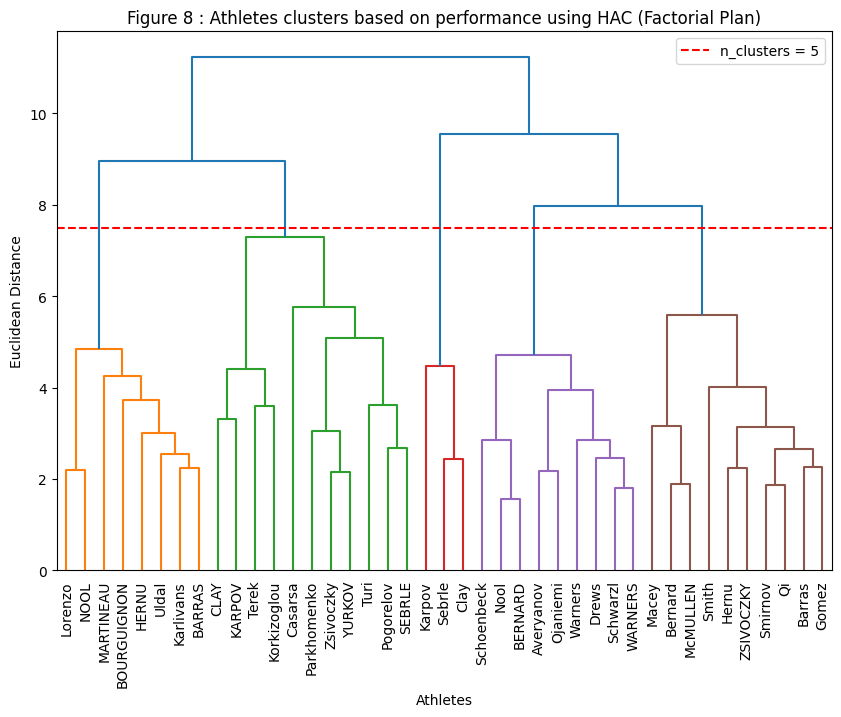

In [37]:
# Plot a dendrogram with Athletes as labels
plt.figure(figsize=(10, 7))

# Integrating Athlete column to the dendrogram
dendrogram(Z, labels=divers['Athlete'].values, leaf_rotation=90, leaf_font_size=10)

# Add titles and labels
plt.title('Figure 8 : Athletes clusters based on performance using HAC (Factorial Plan)')
plt.xlabel('Athletes')
plt.ylabel('Euclidean Distance')

# Add a horizontal line to display clusters' quantity
plt.axhline(y=7.5, color='r', linestyle='--', label="n_clusters = 5")
plt.legend()
plt.savefig('Figure8_athletes_clusters_based_on_performance_using_HAC_(Factorial_Plan).png', dpi= 300)
plt.show()

### Figure 8: Flat Dendrogram from Hierarchical Ascendant Clustering (HAC)

This dendrogram shows the clustering of athletes based on their performance using **Hierarchical Ascendant Classification (HAC)** with **Euclidean distance**.

---

### How was the number of clusters (k = 5) selected?

To determine the optimal number of clusters from the dendrogram, I followed a common visual method:

1. **Observation of vertical linkage lines**:
   - I looked for the **longest vertical segments** in the dendrogram, which represent the largest distances (dissimilarities) between merged clusters.

2. **Cutting the tree**:
   - I drew a **horizontal red dashed line** that intersects these longest vertical lines **before they are joined at the top**.
   - This line defines the level at which we "cut" the dendrogram to form clusters.

3. **Counting intersections**:
   - I then counted how many vertical lines this horizontal line intersected.
   - The result was **5 distinct cuts**, indicating that the data can be meaningfully grouped into **5 clusters**.

---

### Conclusion:

Using the dendrogram’s structure to choose the number of clusters is a visually intuitive and widely used approach in HAC. It ensures that clusters are formed where the data shows clear separation, as indicated by large jumps in the Euclidean distance.

This method allowed me to extract **5 interpretable and well-separated clusters** from the athlete performance data.
